## LSTM (Using Autoregressive Multi-Step Approach)

* Predict future steps recursively using model’s previous output as input.

* Feedback loop is used where predictions become inputs for the next step. 

In the below code We have used Sequence Length = 30 i.e. using only 30 ground truth values from test dataset, whole test dataset will be predicted by appending the predicted values into the array

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.1231 - val_loss: 0.0185
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0164 - val_loss: 0.0131
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0116 - val_loss: 0.0073
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0073 - val_loss: 0.0048
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0059 - val_loss: 0.0109
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0065 - val_loss: 0.0032
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0053 - val_loss: 0.0030
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0059 - val_loss: 0.0046
Epoch 9/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0056 - val_loss: 0.0039
Epoch 10/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0052 - val_loss: 0.0069
Epoch 11/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0051 - val_loss: 0.0031
Epoch 12/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/ste

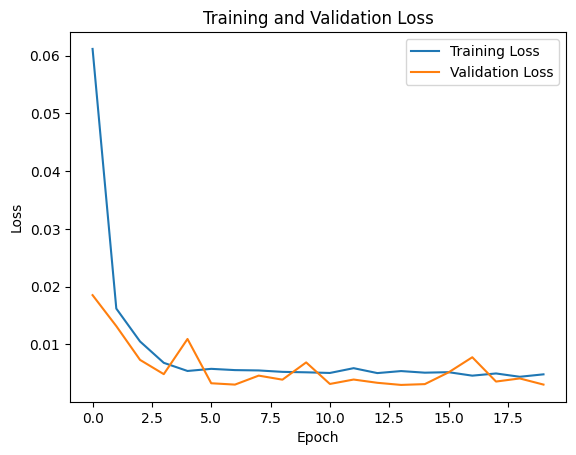

      SN  Actual IP Delay (ms)  Recursive Predicted IP Delay (ms)  \
99   100             17.917871                          17.111258   
100  101             17.835140                          17.050215   
101  102             17.753124                          16.988027   
102  103             17.668009                          16.923436   
103  104             17.627001                          16.854328   
..   ...                   ...                                ...   
195  196             16.888857                          19.976459   
196  197             16.823053                          19.898206   
197  198             16.758204                          19.820823   
198  199             16.668081                          19.743618   
199  200             16.629934                          19.666777   

     Absolute Difference (ms)  
99                   0.806614  
100                  0.784926  
101                  0.765097  
102                  0.744573  
103        

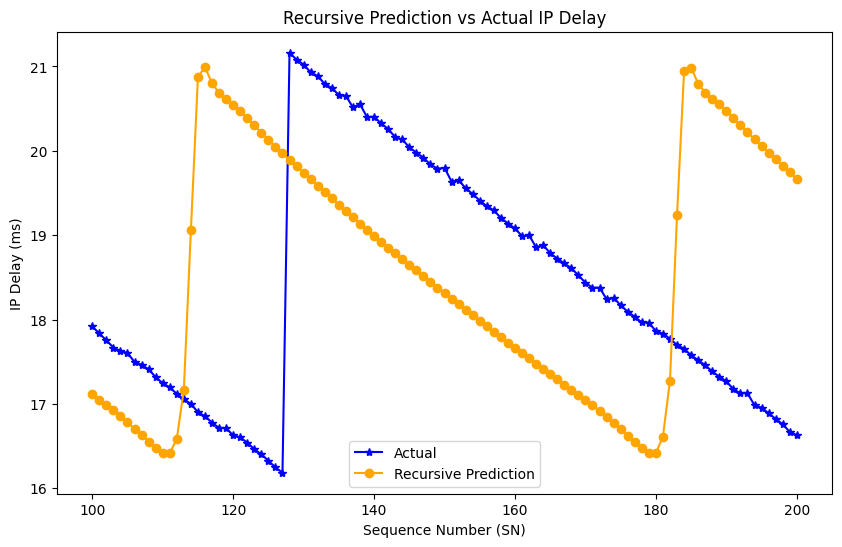

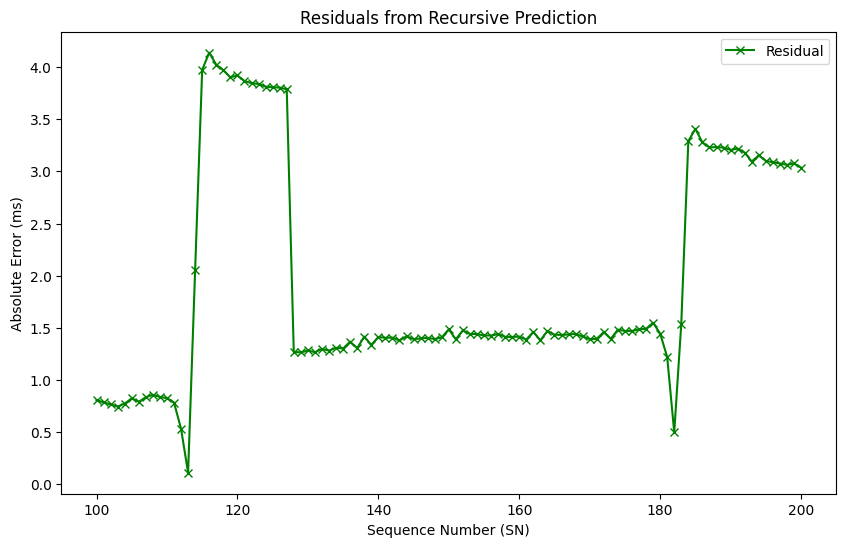

Residual Statistics:
 count    3470.000000
mean        1.632624
std         1.122815
min         0.000089
25%         0.672285
50%         1.459700
75%         2.452185
max         4.812592
Name: Absolute Difference (ms), dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build RNN model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)


# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=100) & (recursive_df['SN'] <=200)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_LSTM_30.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


In the below code We have used Sequence Length = 40 i.e. using only 40 ground truth values from test dataset, whole test dataset will be predicted by appending the predicted values into the array

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0727 - val_loss: 0.0130
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0112 - val_loss: 0.0107
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0087 - val_loss: 0.0070
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0069 - val_loss: 0.0062
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0061 - val_loss: 0.0056
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0060 - val_loss: 0.0056
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0068 - val_loss: 0.0061
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 9/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 10/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0053 - val_loss: 0.0040
Epoch 11/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 12/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/ste

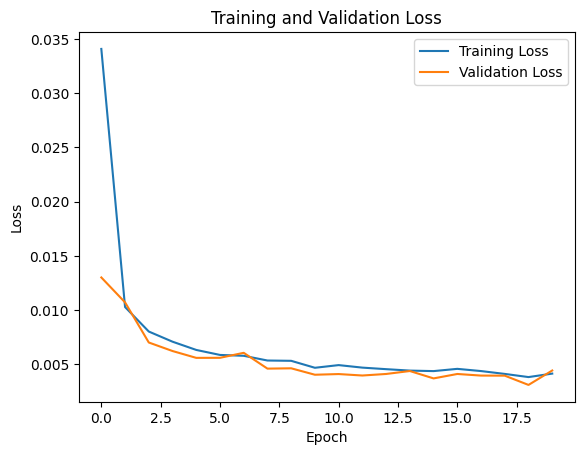

        SN  Actual IP Delay (ms)  Recursive Predicted IP Delay (ms)  \
1099  1100             19.192934                          18.309967   
1100  1101             19.057035                          18.239192   
1101  1102             19.049883                          18.168959   
1102  1103             19.010067                          18.099308   
1103  1104             18.930912                          18.030228   
...    ...                   ...                                ...   
1195  1196             18.123865                          19.371241   
1196  1197             18.088102                          19.291112   
1197  1198             18.037081                          19.211524   
1198  1199             17.940044                          19.132543   
1199  1200             17.877817                          19.054200   

      Absolute Difference (ms)  
1099                  0.882967  
1100                  0.817844  
1101                  0.880924  
1102           

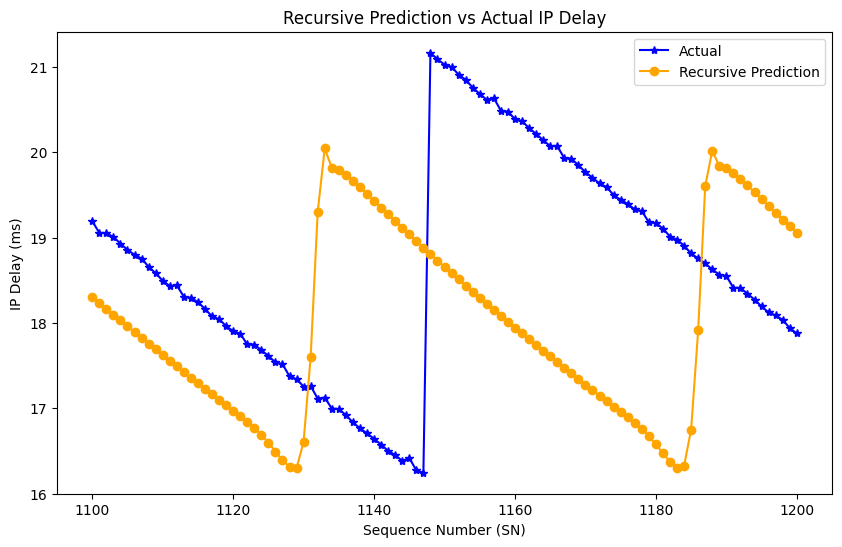

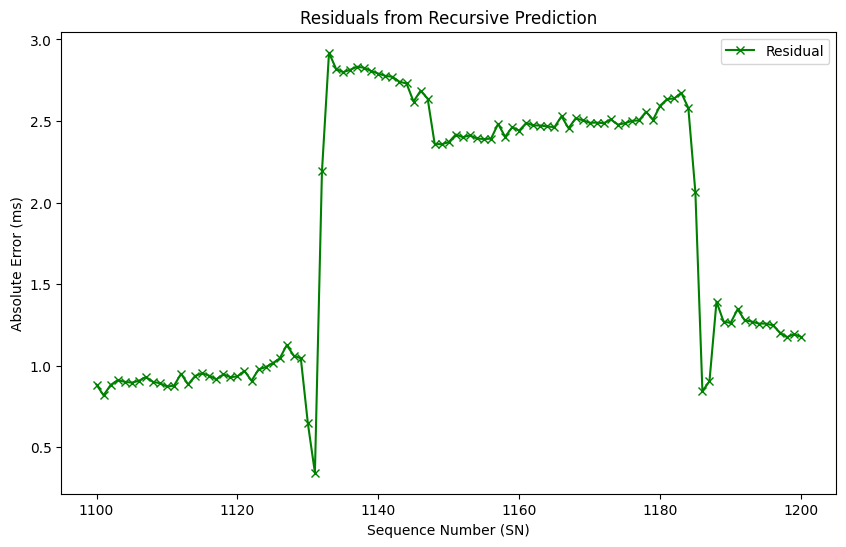

Residual Statistics:
 count    3460.000000
mean        1.545546
std         1.095665
min         0.000273
25%         0.620203
50%         1.398822
75%         2.273302
max         5.036592
Name: Absolute Difference (ms), dtype: float64


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 40

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build RNN model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=1100) & (recursive_df['SN'] <=1200)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_LSTM_40.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


As we can see there was some phase difference in the previous graphs of actual VS predicted values to testify it here in the below code we have performed slicing of test dataset into a small part and printed the values accordingly.

SLICING FROM 1130 to 1230

max and min value of test dataset:  21.865129470825195 16.184091567993164
test dataset [[[0.61851603]
  [0.61780259]
  [0.60340776]
  ...
  [0.20962733]
  [0.20362599]
  [0.18868558]]

 [[0.61780259]
  [0.60340776]
  [0.59090146]
  ...
  [0.20362599]
  [0.18868558]
  [0.1895669 ]]

 [[0.60340776]
  [0.59090146]
  [0.58280175]
  ...
  [0.18868558]
  [0.1895669 ]
  [0.16384086]]

 ...

 [[0.43004029]
  [0.4194645 ]
  [0.41665268]
  ...
  [0.01708075]
  [0.02253651]
  [0.88379218]]

 [[0.4194645 ]
  [0.41665268]
  [0.39218566]
  ...
  [0.02253651]
  [0.88379218]
  [0.87044653]]

 [[0.41665268]
  [0.39218566]
  [0.39201779]
  ...
  [0.88379218]
  [0.87044653]
  [0.86285043]]] [0.1895669  0.16384086 0.16581333 0.14327682 0.14201779 0.12988921
 0.11457109 0.1024425  0.09203458 0.08061944 0.06899446 0.05594259
 0.04733926 0.03537855 0.04117005 0.01582172 0.01086957 0.87711936
 0.86352191 0.85265234 0.84786805 0.8320883  0.82134464 0.80527111
 0.79209334 0.78009065 0.78361591 0.75755414 0.7556

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1022 - val_loss: 0.0165
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0144 - val_loss: 0.0091
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0079 - val_loss: 0.0067
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0082 - val_loss: 0.0060
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0069 - val_loss: 0.0055
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0061 - val_loss: 0.0053
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0059 - val_loss: 0.0049
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0062 - val_loss: 0.0047
Epoch 9/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0049 - val_loss: 0.0045
Epoch 10/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0046 - val_loss: 0.0052
Epoch 11/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0050 - val_loss: 0.0042
Epoch 12/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 

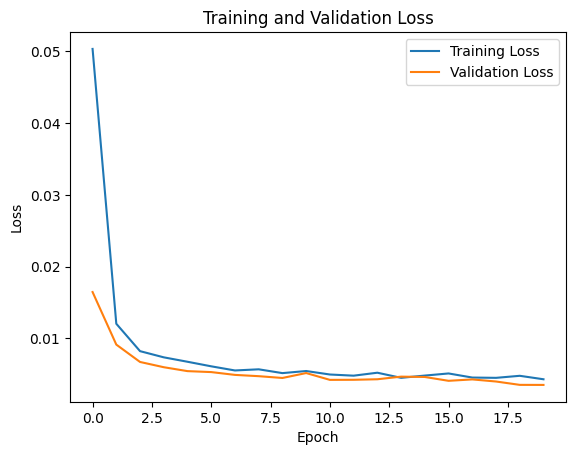

predicted values 0.18138063
denormalized pred val 17.21452179924654
predicted values 0.17076372
denormalized pred val 17.154206711595066
predicted values 0.15947556
denormalized pred val 17.09007829708753
predicted values 0.14627737
denormalized pred val 17.015098840317933
predicted values 0.13058949
denormalized pred val 16.92597538294649
predicted values 0.112975836
denormalized pred val 16.825911573278063
predicted values 0.09397115
denormalized pred val 16.71794522231096
predicted values 0.073685475
denormalized pred val 16.60270154261667
predicted values 0.053376723
denormalized pred val 16.487326754944576
predicted values 0.03880859
denormalized pred val 16.404564648190956
predicted values 0.037976056
denormalized pred val 16.39983498344577
predicted values 0.06365575
denormalized pred val 16.54572229058715
predicted values 0.13656723
denormalized pred val 16.959935206273258
predicted values 0.26705852
denormalized pred val 17.701261150961045
predicted values 0.4101166
denormaliz

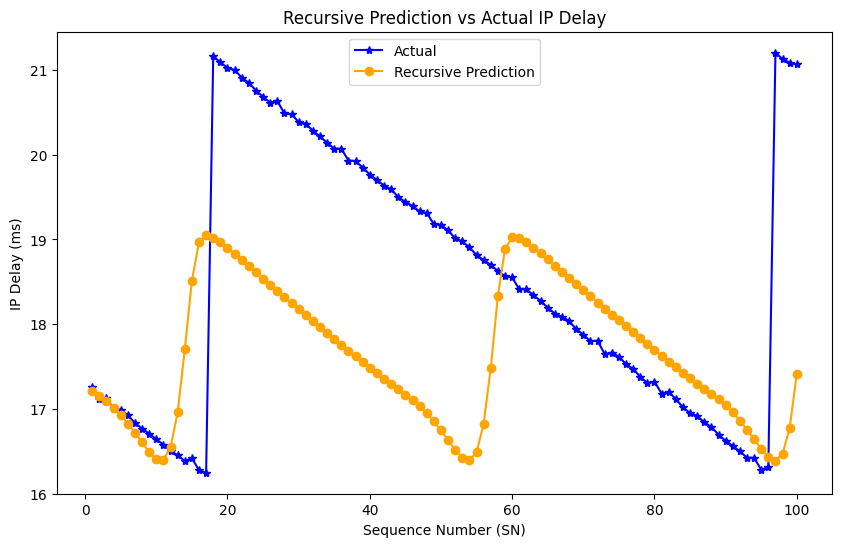

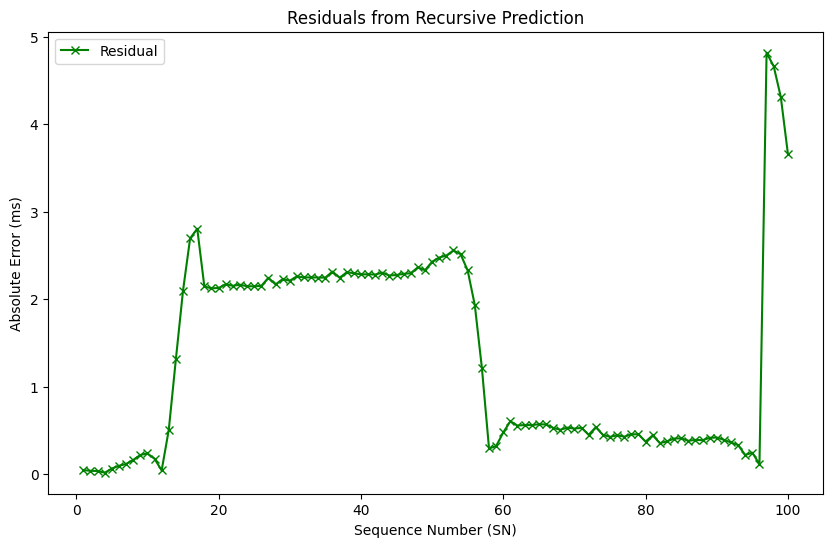

Residual Statistics:
 count    100.000000
mean       1.344380
std        1.134399
min        0.017046
25%        0.392841
50%        0.569550
75%        2.262365
max        4.814861
Name: Absolute Difference (ms), dtype: float64


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

print("max and min value of test dataset: ",max_test,min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 40

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

X_test = X_test[1130:1230]
y_test = y_test[1130:1230]

print("test dataset", X_test, y_test)
print("denorm actual val", (y_test * (max_test - min_test)) + min_test)

# Build RNN model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)
        print("predicted values",predicted_value)
        print("denormalized pred val", (predicted_value * (max_test - min_test)) + min_test)
    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=1) & (recursive_df['SN'] <=100)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_LSTM_40.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


SLICING FROM 1100 to 1200

max and min value of test dataset:  21.865129470825195 16.184091567993164
test dataset [[[0.08061944]
  [0.05963572]
  [0.06106262]
  ...
  [0.54230317]
  [0.53017458]
  [0.52962901]]

 [[0.05963572]
  [0.06106262]
  [0.04943764]
  ...
  [0.53017458]
  [0.52962901]
  [0.50570757]]

 [[0.06106262]
  [0.04943764]
  [0.03504281]
  ...
  [0.52962901]
  [0.50570757]
  [0.50444855]]

 ...

 [[0.75755414]
  [0.7556656 ]
  [0.74001175]
  ...
  [0.35378546]
  [0.34144704]
  [0.33515192]]

 [[0.7556656 ]
  [0.74001175]
  [0.73627665]
  ...
  [0.34144704]
  [0.33515192]
  [0.32617089]]

 [[0.74001175]
  [0.73627665]
  [0.72167198]
  ...
  [0.33515192]
  [0.32617089]
  [0.30909015]]] [0.50570757 0.50444855 0.49743999 0.4835068  0.47049689 0.46042471
 0.4527027  0.43562196 0.42227631 0.4069582  0.39604667 0.39726372
 0.37405573 0.37153769 0.36276649 0.3487074  0.33334732 0.32755582
 0.31328689 0.30292093 0.29784287 0.27543226 0.27526439 0.26363942
 0.25172066 0.23833305 0.23497566 0.20962733 0.2036

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0973 - val_loss: 0.0127
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0109 - val_loss: 0.0088
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0089 - val_loss: 0.0090
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0071 - val_loss: 0.0066
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0067 - val_loss: 0.0058
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0068 - val_loss: 0.0076
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0064 - val_loss: 0.0061
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 9/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0051 - val_loss: 0.0052
Epoch 10/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0072 - val_loss: 0.0042
Epoch 11/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0052 - val_loss: 0.0044
Epoch 12/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 

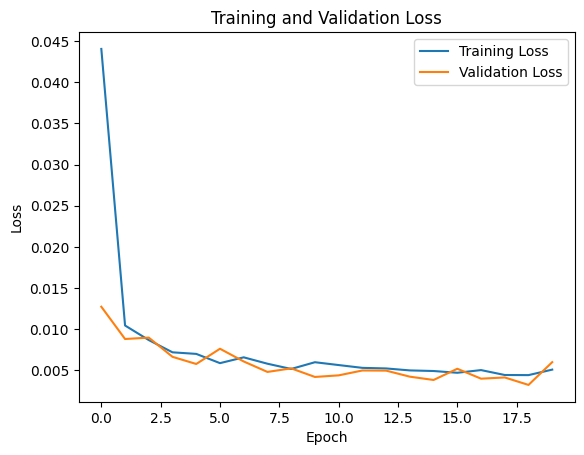

predicted values 0.51476645
denormalized pred val 19.10849930823133
predicted values 0.5046291
denormalized pred val 19.050908472934225
predicted values 0.4948053
denormalized pred val 18.995099267016258
predicted values 0.4851257
denormalized pred val 18.940109004489614
predicted values 0.47543925
denormalized pred val 18.885079970402785
predicted values 0.46572855
denormalized pred val 18.82991311950377
predicted values 0.45598146
denormalized pred val 18.77453954338648
predicted values 0.4461869
denormalized pred val 18.71889625942913
predicted values 0.43634176
denormalized pred val 18.662965659586916
predicted values 0.42642188
denormalized pred val 18.606610434972026
predicted values 0.41641816
denormalized pred val 18.54977894660692
predicted values 0.4063235
denormalized pred val 18.492430729850184
predicted values 0.39613056
denormalized pred val 18.434524304211664
predicted values 0.38583264
denormalized pred val 18.376021406055543
predicted values 0.37542278
denormalized pre

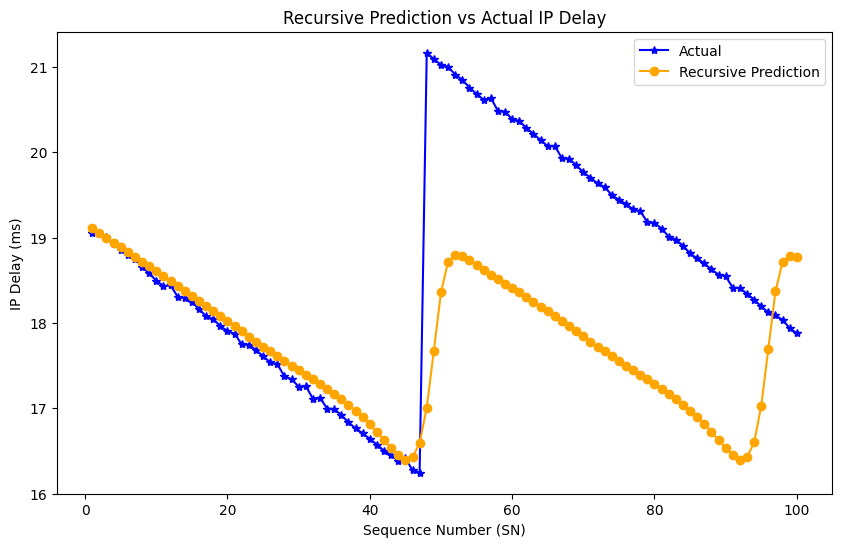

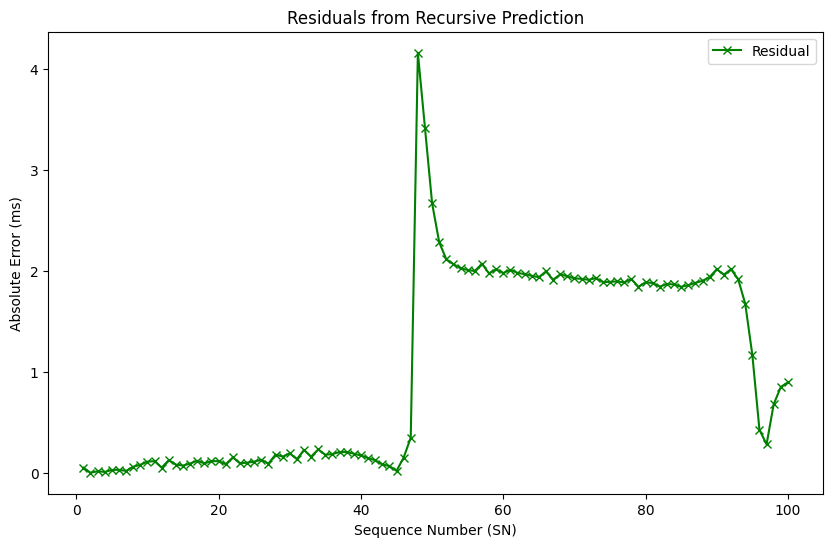

Residual Statistics:
 count    100.000000
mean       1.055800
std        0.983170
min        0.001026
25%        0.115713
50%        0.764184
75%        1.929581
max        4.158378
Name: Absolute Difference (ms), dtype: float64


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

print("max and min value of test dataset: ",max_test,min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 40

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

X_test = X_test[1100:1200]
y_test = y_test[1100:1200]

print("test dataset", X_test, y_test)
print("denorm actual val", (y_test * (max_test - min_test)) + min_test)

# Build RNN model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)
        print("predicted values",predicted_value)
        print("denormalized pred val", (predicted_value * (max_test - min_test)) + min_test)
    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=1) & (recursive_df['SN'] <=100)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_LSTM_40.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


From the above graphs, we can conclude that initially diffrence b/w actual and predicted values is very less and as it moves forward, the diffrence starts increasing gradually and as a result the phase diffrence that we see is actually a modelling error.

SLICING FROM 1170 to 1270

max and min value of test dataset:  21.865129470825195 16.184091567993164
test dataset [[[0.1895669 ]
  [0.16384086]
  [0.16581333]
  ...
  [0.6586369 ]
  [0.64512338]
  [0.63068659]]

 [[0.16384086]
  [0.16581333]
  [0.14327682]
  ...
  [0.64512338]
  [0.63068659]
  [0.61943932]]

 [[0.16581333]
  [0.14327682]
  [0.14201779]
  ...
  [0.63068659]
  [0.61943932]
  [0.60743663]]

 ...

 [[0.87044653]
  [0.86285043]
  [0.8596609 ]
  ...
  [0.47116837]
  [0.45551452]
  [0.45538862]]

 [[0.86285043]
  [0.8596609 ]
  [0.85441497]
  ...
  [0.45551452]
  [0.45538862]
  [0.43020816]]

 [[0.8596609 ]
  [0.85441497]
  [0.82659057]
  ...
  [0.45538862]
  [0.43020816]
  [0.42894914]]] [0.61943932 0.60743663 0.60021823 0.58347322 0.57382072 0.56521739
 0.55392815 0.55057076 0.52753064 0.52593587 0.51447876 0.4979436
 0.49160651 0.47910022 0.46311063 0.45287057 0.44267249 0.43004029
 0.4194645  0.41665268 0.39218566 0.39201779 0.37984724 0.36805439
 0.35378546 0.34144704 0.33515192 0.32617089 0.30909

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_21 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - loss: 0.0891 - val_loss: 0.0144
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0131 - val_loss: 0.0138
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - loss: 0.0095 - val_loss: 0.0072
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0072 - val_loss: 0.0066
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0066 - val_loss: 0.0059
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0067 - val_loss: 0.0055
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0064 - val_loss: 0.0053
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0058 - val_loss: 0.0061
Epoch 9/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0057 - val_loss: 0.0047
Epoch 10/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0048 - val_loss: 0.0049
Epoch 11/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 12/20
224/224 ━━━━━━━━━━━━━━━━━━━━

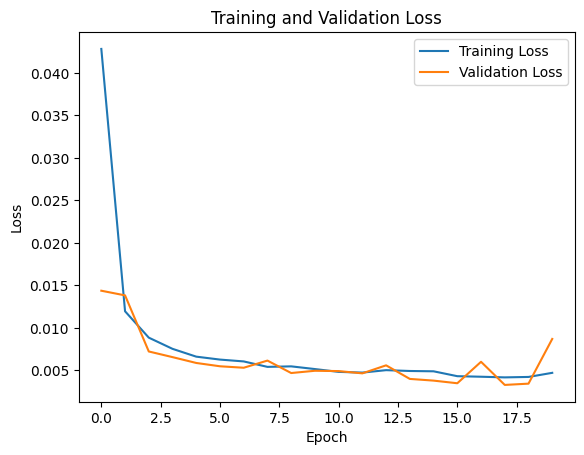

predicted values 0.639508
denormalized pred val 19.81716080604201
predicted values 0.6326531
denormalized pred val 19.778217906036843
predicted values 0.62522113
denormalized pred val 19.735996523536414
predicted values 0.6174485
denormalized pred val 19.691839949189216
predicted values 0.6091882
denormalized pred val 19.644912816715987
predicted values 0.60051405
denormalized pred val 19.595634671645712
predicted values 0.59137577
denormalized pred val 19.543719721866637
predicted values 0.5816574
denormalized pred val 19.488509358779993
predicted values 0.5713381
denormalized pred val 19.429885066699626
predicted values 0.56036115
denormalized pred val 19.367524482959197
predicted values 0.5487835
denormalized pred val 19.30175132469003
predicted values 0.5365071
denormalized pred val 19.23200890678345
predicted values 0.5235663
denormalized pred val 19.158491594964744
predicted values 0.5101917
denormalized pred val 19.08250983410653
predicted values 0.4964767
denormalized pred val 

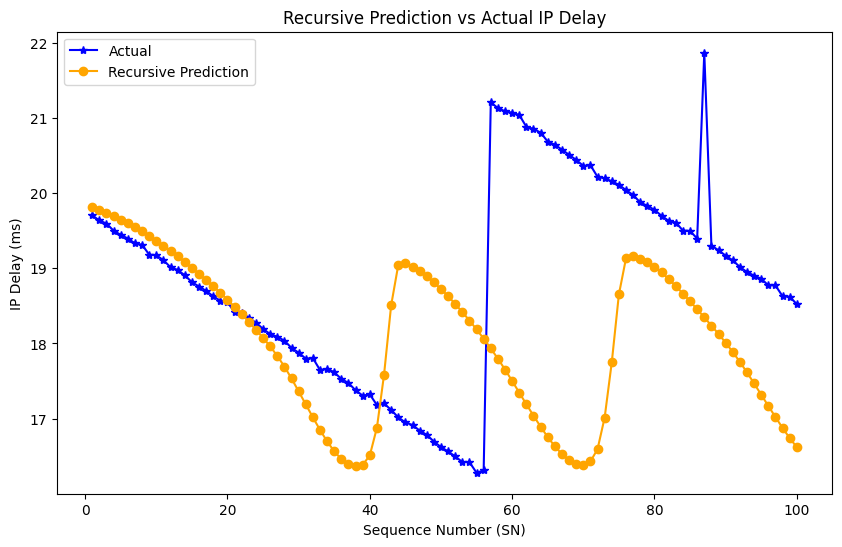

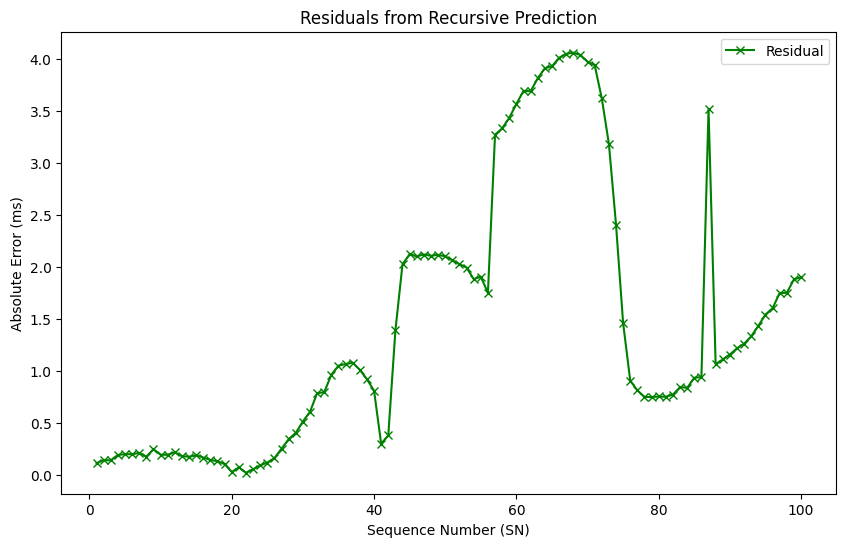

Residual Statistics:
 count    100.000000
mean       1.418712
std        1.268802
min        0.022616
25%        0.241424
50%        1.031288
75%        2.073509
max        4.058803
Name: Absolute Difference (ms), dtype: float64


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
train_data = pd.read_csv('TR1.csv')
test_data = pd.read_csv('TE1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_test) / (max_test - min_test)

print("max and min value of test dataset: ",max_test,min_test)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 40

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

X_test = X_test[1170:1270]
y_test = y_test[1170:1270]

print("test dataset", X_test, y_test)
print("denorm actual val", (y_test * (max_test - min_test)) + min_test)

# Build RNN model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)
        print("predicted values",predicted_value)
        print("denormalized pred val", (predicted_value * (max_test - min_test)) + min_test)
    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
recursive_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Filter comparison_df for SN of your choice
filtered_df = recursive_df[(recursive_df['SN'] >=1) & (recursive_df['SN'] <=100)]

# Print filtered comparison
print(filtered_df)

# Plot Actual vs Recursive Predicted
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Actual IP Delay (ms)'], label='Actual', color='blue', marker='*')
plt.plot(filtered_df['SN'], filtered_df['Recursive Predicted IP Delay (ms)'], label='Recursive Prediction', color='orange', marker='o')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('IP Delay (ms)')
plt.title('Recursive Prediction vs Actual IP Delay')
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(filtered_df['SN'], filtered_df['Absolute Difference (ms)'], label='Residual', color='green', marker='x')
plt.xlabel('Sequence Number (SN)')
plt.ylabel('Absolute Error (ms)')
plt.title('Residuals from Recursive Prediction')
plt.legend()
plt.show()

# Save results
recursive_df.to_csv('recursive_test_LSTM_40.csv', index=False)

# Optional: print summary stats
print("Residual Statistics:\n", recursive_df['Absolute Difference (ms)'].describe())


In [ ]:
print(X_test.shape, y_test.shape)
print(X_test[:5].shape, y_test[:5].shape)

(3470, 30, 1) (3470,)
(5, 30, 1) (5,)


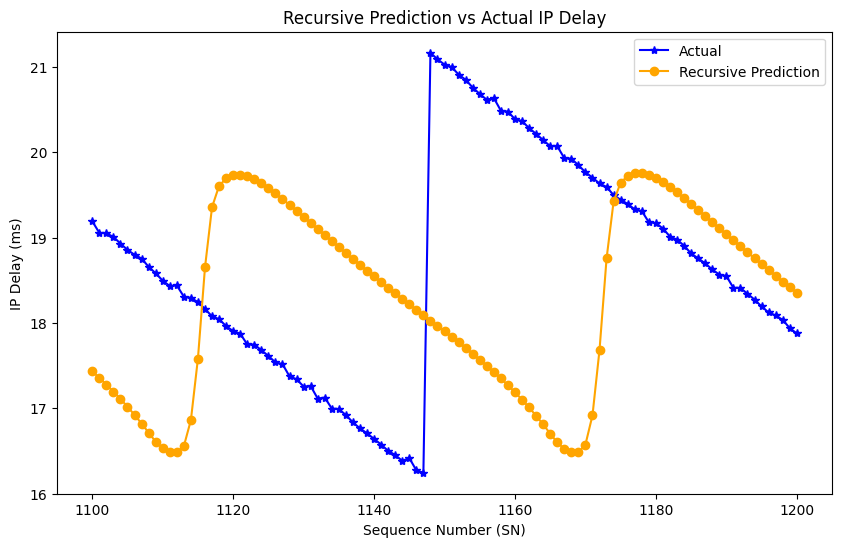

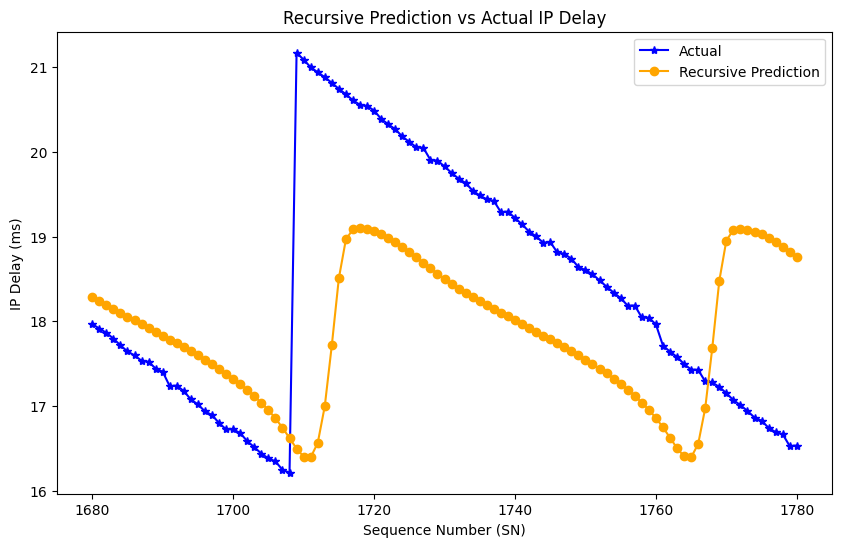

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0733 - val_loss: 0.0203
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0157 - val_loss: 0.0141
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0133 - val_loss: 0.0111
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0097 - val_loss: 0.0108
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0107 - val_loss: 0.0099
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0090 - val_loss: 0.0084
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0092 - val_loss: 0.0082
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0070 - val_loss: 0.0067
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0066 - val_loss: 0.0070
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0063 - val_loss: 0.0073
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0071 - val_loss: 0.0142
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0084 

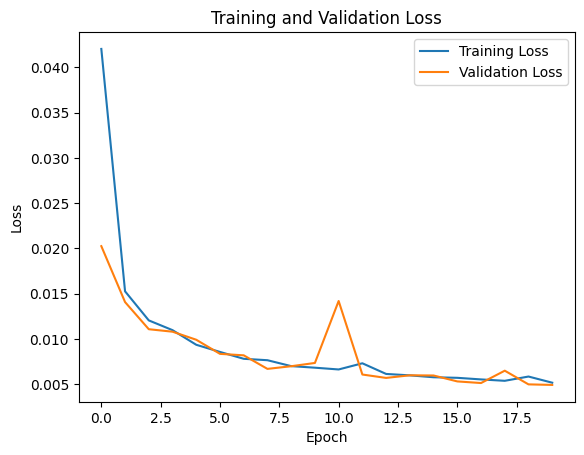

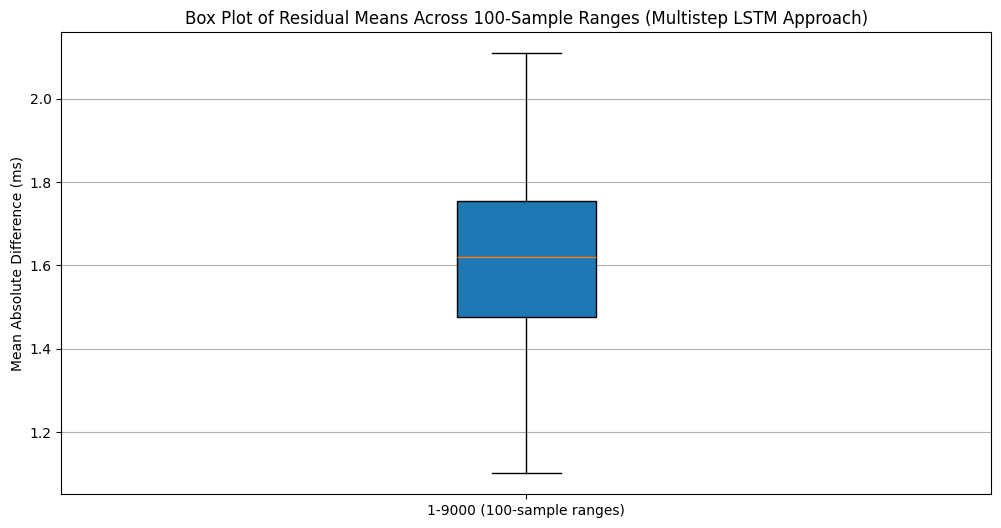

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    90.000000    90.000000      90.000000
mean   4451.000000  4550.000000       1.610396
std    2612.470096  2612.470096       0.239306
min       1.000000   100.000000       1.100857
25%    2226.000000  2325.000000       1.476537
50%    4451.000000  4550.000000       1.621205
75%    6676.000000  6775.000000       1.754922
max    8901.000000  9000.000000       2.109273


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load data
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

# Normalize IP Delay (min-max scaling)
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_train) / (max_test - min_train)

# Create sequences
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build RNN model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)


# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

# Build comparison DataFrame
result_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# Calculate Residual Means for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_means = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty: # Ensure enough data
        residual_mean = range_df['Absolute Difference (ms)'].mean()
        residual_means.append(residual_mean)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(residual_means, patch_artist=True)
plt.title('Box Plot of Residual Means Across 100-Sample Ranges (Multistep LSTM Approach)')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], ['1-9000 (100-sample ranges)'])  # Single box for all ranges
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Mean': residual_means
})
result_df_ranges.to_csv('residual_means_by_range.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())


c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0704 - val_loss: 0.0179
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0144 - val_loss: 0.0115
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0113 - val_loss: 0.0128
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0094 - val_loss: 0.0096
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0097 - val_loss: 0.0083
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0065 - val_loss: 0.0078
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0056 - val_loss: 0.0066
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0074 - val_loss: 0.0057
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0061 - val_loss: 0.0050
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0054 - val_loss: 0.0048
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

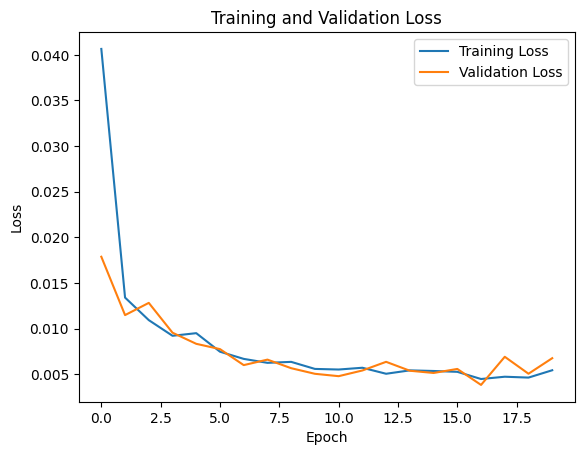

C:\Users\karti\AppData\Local\Temp\ipykernel_6780\3417975951.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_variances, patch_artist=True, labels=['Hybrid Approach (Future Steps = 10)', 'Fully Recursive Approach'])


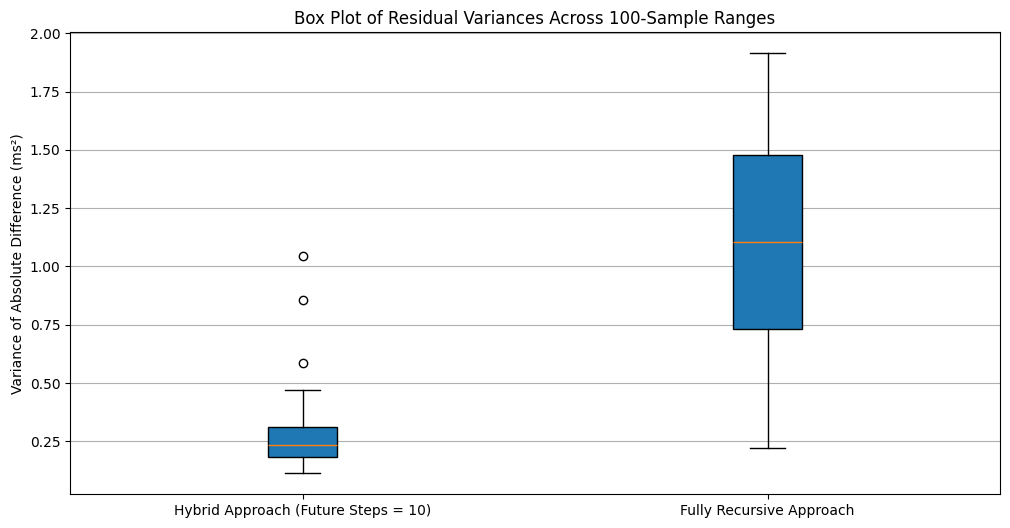

Residual Variances Summary (Hybrid):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           0.264383
std    2612.470096  2612.470096           0.139584
min       1.000000   100.000000           0.113497
25%    2226.000000  2325.000000           0.182166
50%    4451.000000  4550.000000           0.236181
75%    6676.000000  6775.000000           0.311946
max    8901.000000  9000.000000           1.046794

Residual Variances Summary (Fully Recursive):
        Range_Start    Range_End  Residual_Variance
count    90.000000    90.000000          90.000000
mean   4451.000000  4550.000000           1.132150
std    2612.470096  2612.470096           0.421753
min       1.000000   100.000000           0.221835
25%    2226.000000  2325.000000           0.733220
50%    4451.000000  4550.000000           1.104505
75%    6676.000000  6775.000000           1.479865
max    8901.000000  9000.000000           1.913

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

# Normalize training data
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

# Normalize test data using training min and max for consistency
min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# -------------------------
# Prediction Functions
# -------------------------

# Fully Recursive Prediction Function
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Hybrid Prediction Function
def hybrid_prediction(test_values, sequence_length, future_steps, min_test, max_test):
    predictions = []
    actuals = []

    i = 0
    while i + sequence_length + future_steps <= len(test_values):
        input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
        block_preds = []
        current_seq = input_seq.copy()

        for _ in range(future_steps):
            pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
            next_val = pred.flatten()[0]
            block_preds.append(next_val)
            current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

        predictions.extend(block_preds)
        actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
        actuals.extend(actual_block)
        i += future_steps

    preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
    actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

    return preds_denorm, actuals_denorm

# -------------------------
# Calculate Residual Variances for Both Approaches
# -------------------------
# Fully Recursive Approach
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

result_df_recursive = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_variances_recursive = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df_recursive[(result_df_recursive['SN'] >= start_idx + 1) & (result_df_recursive['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) > 0:  # Ensure some data
        residual_variance = range_df['Absolute Difference (ms)'].var()
        residual_variances_recursive.append(residual_variance)

# Hybrid Approach
future_steps = 10
preds_hybrid_denorm, actuals_hybrid_denorm = hybrid_prediction(test_values, sequence_length, future_steps, min_test, max_test)

result_df_hybrid = pd.DataFrame({
    'SN': range(1, len(actuals_hybrid_denorm) + 1),
    'Actual IP Delay (ms)': actuals_hybrid_denorm,
    'Predicted IP Delay (ms)': preds_hybrid_denorm,
    'Absolute Difference (ms)': abs(actuals_hybrid_denorm - preds_hybrid_denorm)
})

residual_variances_hybrid = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df_hybrid[(result_df_hybrid['SN'] >= start_idx + 1) & (result_df_hybrid['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        residual_variance = range_df['Absolute Difference (ms)'].var()
        residual_variances_hybrid.append(residual_variance)

# -------------------------
# Plot Box Plot of Residual Variances for Both Approaches
# -------------------------
all_variances = [residual_variances_hybrid, residual_variances_recursive]
plt.figure(figsize=(12, 6))
plt.boxplot(all_variances, patch_artist=True, labels=['Hybrid Approach (Future Steps = 10)', 'Fully Recursive Approach'])
plt.title('Box Plot of Residual Variances Across 100-Sample Ranges')
plt.ylabel('Variance of Absolute Difference (ms²)')
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges_hybrid = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Variance': residual_variances_hybrid
})
result_df_ranges_recursive = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Variance': residual_variances_recursive
})
result_df_ranges_hybrid.to_csv('residual_variances_hybrid_by_range.csv', index=False)
result_df_ranges_recursive.to_csv('residual_variances_recursive_by_range.csv', index=False)
print("Residual Variances Summary (Hybrid):\n", result_df_ranges_hybrid.describe())
print("\nResidual Variances Summary (Fully Recursive):\n", result_df_ranges_recursive.describe())

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.1227 - val_loss: 0.0315
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0258 - val_loss: 0.0166
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0156 - val_loss: 0.0137
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0130 - val_loss: 0.0217
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0158 - val_loss: 0.0097
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0081 - val_loss: 0.0079
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0082 - val_loss: 0.0090
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0075 - val_loss: 0.0075
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0063 - val_loss: 0.0099
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0064 - val_loss: 0.0063
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0

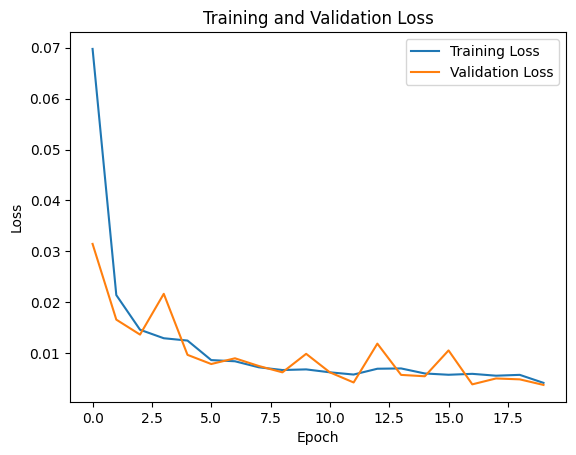

C:\Users\karti\AppData\Local\Temp\ipykernel_6780\1806213171.py:165: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_means, patch_artist=True, labels=['Hybrid Approach (Future Steps = 10)', 'Fully Recursive Approach'])


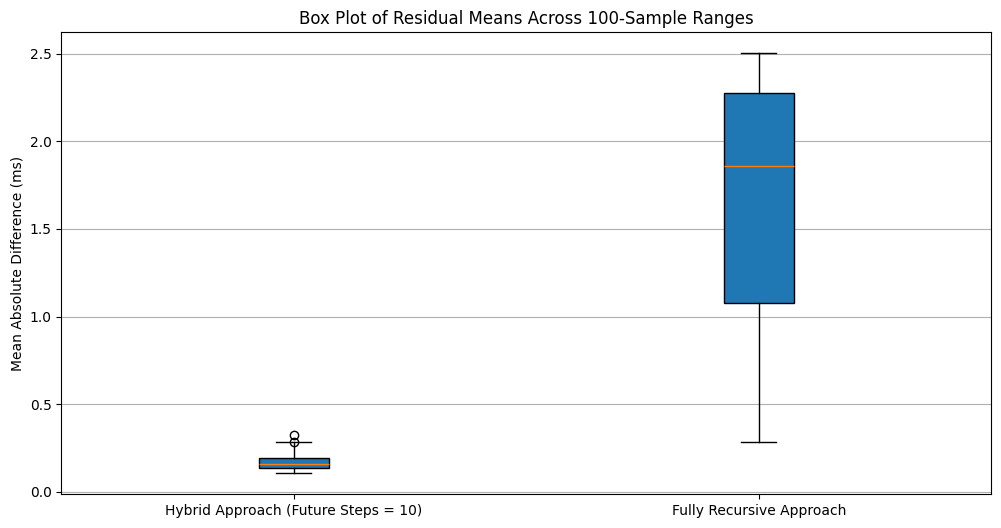

Residual Means Summary (Hybrid):
        Range_Start    Range_End  Residual_Mean
count    90.000000    90.000000      90.000000
mean   4451.000000  4550.000000       0.168662
std    2612.470096  2612.470096       0.043296
min       1.000000   100.000000       0.105668
25%    2226.000000  2325.000000       0.135829
50%    4451.000000  4550.000000       0.161161
75%    6676.000000  6775.000000       0.194682
max    8901.000000  9000.000000       0.322531

Residual Means Summary (Fully Recursive):
        Range_Start    Range_End  Residual_Mean
count    90.000000    90.000000      90.000000
mean   4451.000000  4550.000000       1.622690
std    2612.470096  2612.470096       0.719536
min       1.000000   100.000000       0.283834
25%    2226.000000  2325.000000       1.075089
50%    4451.000000  4550.000000       1.859042
75%    6676.000000  6775.000000       2.275775
max    8901.000000  9000.000000       2.502367


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

# Normalize training data
min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

# Normalize test data using training min and max for consistency
min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# -------------------------
# Prediction Functions
# -------------------------

# Fully Recursive Prediction Function
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Hybrid Prediction Function
def hybrid_prediction(test_values, sequence_length, future_steps, min_test, max_test):
    predictions = []
    actuals = []

    i = 0
    while i + sequence_length + future_steps <= len(test_values):
        input_seq = test_values[i:i + sequence_length].reshape(-1, 1)
        block_preds = []
        current_seq = input_seq.copy()

        for _ in range(future_steps):
            pred = model.predict(current_seq.reshape(1, sequence_length, 1), verbose=0)
            next_val = pred.flatten()[0]
            block_preds.append(next_val)
            current_seq = np.append(current_seq[1:], [[next_val]], axis=0)

        predictions.extend(block_preds)
        actual_block = test_values[i + sequence_length : i + sequence_length + future_steps]
        actuals.extend(actual_block)
        i += future_steps

    preds_denorm = (np.array(predictions) * (max_test - min_test)) + min_test
    actuals_denorm = (np.array(actuals) * (max_test - min_test)) + min_test

    return preds_denorm, actuals_denorm

# -------------------------
# Calculate Residual Means for Both Approaches
# -------------------------
# Fully Recursive Approach
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)
recursive_preds_denorm = (recursive_preds * (max_test - min_test)) + min_test
actual_test_denorm = (y_test * (max_test - min_test)) + min_test

result_df_recursive = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

range_size = 100
num_ranges = len(test_values) // range_size  # 9000 // 100 = 90
residual_means_recursive = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df_recursive[(result_df_recursive['SN'] >= start_idx + 1) & (result_df_recursive['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) > 0:  # Ensure some data
        residual_mean = range_df['Absolute Difference (ms)'].mean()
        residual_means_recursive.append(residual_mean)

# Hybrid Approach
future_steps = 10
preds_hybrid_denorm, actuals_hybrid_denorm = hybrid_prediction(test_values, sequence_length, future_steps, min_test, max_test)

result_df_hybrid = pd.DataFrame({
    'SN': range(1, len(actuals_hybrid_denorm) + 1),
    'Actual IP Delay (ms)': actuals_hybrid_denorm,
    'Predicted IP Delay (ms)': preds_hybrid_denorm,
    'Absolute Difference (ms)': abs(actuals_hybrid_denorm - preds_hybrid_denorm)
})

residual_means_hybrid = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df_hybrid[(result_df_hybrid['SN'] >= start_idx + 1) & (result_df_hybrid['SN'] <= end_idx)]
    if not range_df.empty and len(range_df) >= future_steps:  # Ensure enough data
        residual_mean = range_df['Absolute Difference (ms)'].mean()
        residual_means_hybrid.append(residual_mean)

# -------------------------
# Plot Box Plot of Residual Means for Both Approaches
# -------------------------
all_means = [residual_means_hybrid, residual_means_recursive]
plt.figure(figsize=(12, 6))
plt.boxplot(all_means, patch_artist=True, labels=['Hybrid Approach (Future Steps = 10)', 'Fully Recursive Approach'])
plt.title('Box Plot of Residual Means Across 100-Sample Ranges')
plt.ylabel('Mean Absolute Difference (ms)')
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges_hybrid = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Mean': residual_means_hybrid
})
result_df_ranges_recursive = pd.DataFrame({
    'Range_Start': [i * 100 + 1 for i in range(num_ranges)],
    'Range_End': [(i + 1) * 100 for i in range(num_ranges)],
    'Residual_Mean': residual_means_recursive
})
result_df_ranges_hybrid.to_csv('residual_means_hybrid_by_range.csv', index=False)
result_df_ranges_recursive.to_csv('residual_means_recursive_by_range.csv', index=False)
print("Residual Means Summary (Hybrid):\n", result_df_ranges_hybrid.describe())
print("\nResidual Means Summary (Fully Recursive):\n", result_df_ranges_recursive.describe())

c:\ML\PYTHON\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1180 - val_loss: 0.0270
Epoch 2/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0223 - val_loss: 0.0166
Epoch 3/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0134 - val_loss: 0.0107
Epoch 4/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0114 - val_loss: 0.0099
Epoch 5/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0094 - val_loss: 0.0085
Epoch 6/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0091 - val_loss: 0.0092
Epoch 7/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0077 - val_loss: 0.0079
Epoch 8/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0079 - val_loss: 0.0078
Epoch 9/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0079 - val_loss: 0.0081
Epoch 10/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0076 - val_loss: 0.0073
Epoch 11/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0061 - val_loss: 0.0094
Epoch 12/20
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0076 - v

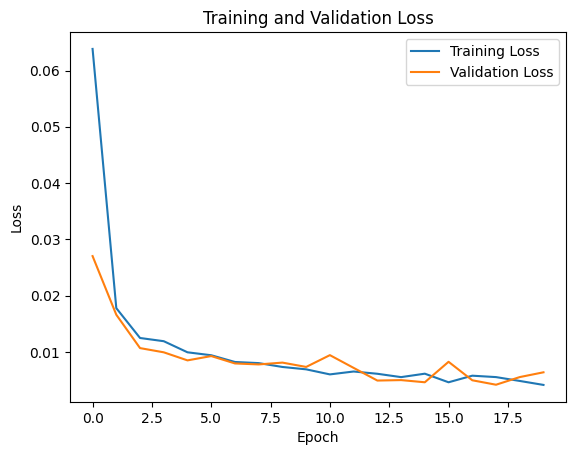

Range-Based Prediction Statistics:
Mean Absolute Difference:
     Range_Start  Range_End  Mean Absolute Difference (ms)
0             1        100                       0.333381
1           101        200                       0.276049
2           201        300                       0.835684
3           301        400                       0.651211
4           401        500                       0.476144
..          ...        ...                            ...
84         8401       8500                       0.291688
85         8501       8600                       0.115797
86         8601       8700                       0.137438
87         8701       8800                       0.143949
88         8801       8900                       0.292313

[89 rows x 3 columns]
90th Quantile Absolute Difference:
     Range_Start  Range_End  90th Quantile Absolute Difference (ms)
0             1        100                                0.279692
1           101        200                       

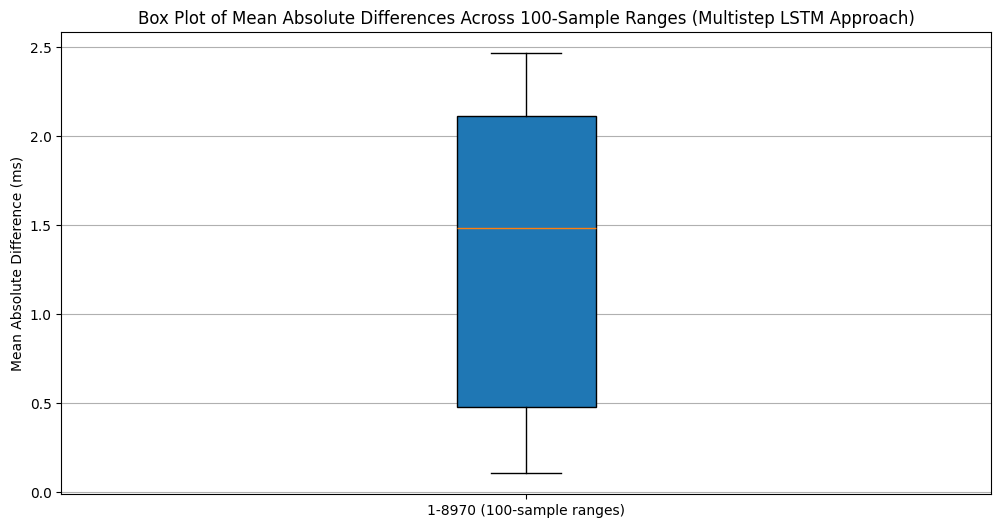

Residual Means Summary:
        Range_Start    Range_End  Residual_Mean
count    89.000000    89.000000      89.000000
mean   4401.000000  4500.000000       1.318460
std    2583.602137  2583.602137       0.809116
min       1.000000   100.000000       0.106161
25%    2201.000000  2300.000000       0.476144
50%    4401.000000  4500.000000       1.484696
75%    6601.000000  6700.000000       2.112537
max    8801.000000  8900.000000       2.465194


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# -------------------------
# Load and Normalize
# -------------------------
train_data = pd.read_csv('TE1.csv')
test_data = pd.read_csv('TR1.csv')

min_train = train_data['IP Delay (ms)'].min()
max_train = train_data['IP Delay (ms)'].max()
train_data['Normalized IP Delay'] = (train_data['IP Delay (ms)'] - min_train) / (max_train - min_train)

min_test = test_data['IP Delay (ms)'].min()
max_test = test_data['IP Delay (ms)'].max()
test_data['Normalized IP Delay'] = (test_data['IP Delay (ms)'] - min_train) / (max_test - min_train)

# -------------------------
# Create Sequences
# -------------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 30

# Prepare training and testing sets
train_values = train_data['Normalized IP Delay'].values
X_train, y_train = create_sequences(train_values, sequence_length)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

test_values = test_data['Normalized IP Delay'].values
X_test, y_test = create_sequences(test_values, sequence_length)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# -------------------------
# Build and Train Model
# -------------------------
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

# Plot training history
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Recursive full prediction function ---
def recursive_full_test_prediction(initial_sequence, model, total_steps):
    current_sequence = initial_sequence.copy()
    recursive_predictions = []

    for _ in range(total_steps):
        next_pred = model.predict(current_sequence.reshape(1, current_sequence.shape[0], 1), verbose=0)
        predicted_value = next_pred.flatten()[0]
        recursive_predictions.append(predicted_value)
        current_sequence = np.append(current_sequence[1:], predicted_value).reshape(-1, 1)

    return np.array(recursive_predictions)

# Start from the first test sequence
initial_sequence = X_test[0].reshape(-1, 1)
recursive_steps = len(y_test)
recursive_preds = recursive_full_test_prediction(initial_sequence, model, recursive_steps)

# Denormalize predictions
recursive_preds_denorm = (recursive_preds * (max_test - min_train)) + min_train
actual_test_denorm = (y_test * (max_test - min_train)) + min_train

# Build comparison DataFrame
result_df = pd.DataFrame({
    'SN': range(1, recursive_steps + 1),
    'Actual IP Delay (ms)': actual_test_denorm,
    'Recursive Predicted IP Delay (ms)': recursive_preds_denorm,
    'Absolute Difference (ms)': abs(actual_test_denorm - recursive_preds_denorm)
})

# -------------------------
# Calculate Statistics for Each 100-Sample Range
# -------------------------
range_size = 100
num_ranges = len(result_df) // range_size  # Adjusted to match prediction length
range_starts = [i * range_size + 1 for i in range(num_ranges)]
range_ends = [(i + 1) * range_size for i in range(num_ranges)]

mean_absolute_diff_range = []
quantile_90_absolute_diff_range = []
variance_absolute_diff_range = []

for range_idx in range(num_ranges):
    start_idx = range_idx * range_size
    end_idx = (range_idx + 1) * range_size
    range_df = result_df[(result_df['SN'] >= start_idx + 1) & (result_df['SN'] <= end_idx)]
    if not range_df.empty:  # Ensure enough data
        mean_absolute_diff_range.append(range_df['Absolute Difference (ms)'].mean())
        quantile_90_absolute_diff_range.append(range_df['Absolute Difference (ms)'].quantile(0.90))
        variance_absolute_diff_range.append(range_df['Absolute Difference (ms)'].var())

# Store each statistic in a separate CSV file
mean_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Mean Absolute Difference (ms)': mean_absolute_diff_range
})
mean_df.to_csv('mean_multistep_range.csv', index=False)

quantile_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    '90th Quantile Absolute Difference (ms)': quantile_90_absolute_diff_range
})
quantile_df.to_csv('90thquantile_multistep_range.csv', index=False)

variance_df = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Variance Absolute Difference (ms²)': variance_absolute_diff_range
})
variance_df.to_csv('variance_multistep_range.csv', index=False)

print("Range-Based Prediction Statistics:")
print("Mean Absolute Difference:\n", mean_df)
print("90th Quantile Absolute Difference:\n", quantile_df)
print("Variance Absolute Difference:\n", variance_df)

# -------------------------
# Plot Box Plot of Residual Means
# -------------------------
plt.figure(figsize=(12, 6))
plt.boxplot(mean_absolute_diff_range, patch_artist=True)
plt.title('Box Plot of Mean Absolute Differences Across 100-Sample Ranges (Multistep LSTM Approach)')
plt.ylabel('Mean Absolute Difference (ms)')
plt.xticks([1], [f'1-{len(result_df)} (100-sample ranges)'])  # Updated to reflect actual data length
plt.grid(axis='y')
plt.show()

# Save results for reference
result_df_ranges = pd.DataFrame({
    'Range_Start': range_starts,
    'Range_End': range_ends,
    'Residual_Mean': mean_absolute_diff_range  # Using mean as the representative statistic for the range
})
result_df_ranges.to_csv('residual_means_by_range.csv', index=False)
print("Residual Means Summary:\n", result_df_ranges.describe())